In [ ]:
import torch
!pip install torch-geometric
!pip install ogb
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage
torch.serialization.add_safe_globals([DataEdgeAttr, DataTensorAttr, GlobalStorage])

from ogb.nodeproppred import PygNodePropPredDataset
dataset = PygNodePropPredDataset(name="ogbn-arxiv")
data = dataset[0]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.1 MB/s eta 0:00:00


Downloaded 0.08 GB: 100%|██████████| 81/81 [00:16<00:00,  5.00it/s]


Extracting dataset/arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 7584.64it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 140.76it/s]

Saving...



Done!


Step 2 — Represent the graph as an edge list

In [ ]:
print(data.edge_index)
print("Shape:", data.edge_index.shape)   # [2, num_edges]

tensor([[104447,  15858, 107156,  ...,  45118,  45118,  45118],
        [ 13091,  47283,  69161,  ..., 162473, 162537,  72717]])
Shape: torch.Size([2, 1166243])


Step 3 — Describe node features

In [ ]:
print("Feature matrix shape:", data.x.shape)   # [num_nodes, 128]
print("Sample feature vector:", data.x[0])
print("Feature min/max/mean:", data.x.min().item(), data.x.max().item(), data.x.mean().item())

Feature matrix shape: torch.Size([169343, 128])
Sample feature vector: tensor([-0.0579, -0.0525, -0.0726, -0.0266,  0.1304, -0.2414, -0.4492, -0.0184,
        -0.0872,  0.1123, -0.0921, -0.2896, -0.0810,  0.0745, -0.1562, -0.0974,
         0.1194,  0.6458,  0.0774, -0.0939, -0.4004,  0.3114, -0.5418,  0.0805,
        -0.0069,  0.5423, -0.0122, -0.1808,  0.0165,  0.0508, -0.2083, -0.0870,
         0.0124,  0.2817,  0.1004, -0.1643,  0.0269,  0.0782,  0.0795, -0.0134,
         0.2915,  0.0416, -0.1414, -0.1345,  0.0162,  0.2810, -0.0919, -0.2403,
         0.4618,  0.1873,  0.1533,  0.0331,  0.0108,  0.0124, -0.1589,  0.0980,
         0.0305,  0.0162, -0.0957,  0.0521,  0.3218, -0.1057,  0.2229, -0.1206,
        -0.1723,  0.3954,  0.0883, -0.2219,  0.2310, -0.2096, -0.1125, -0.0644,
         0.0697, -0.1574,  0.0223, -0.4190,  0.1344,  0.2605,  0.0417, -0.0935,
        -0.0516, -0.0255,  0.7744,  0.0581,  0.0452,  0.0571, -0.5482, -0.0464,
         0.8728,  0.0119,  0.3891, -0.0859,  0.11

Step 4 — Visualize a sample subgraph (not the whole thing)

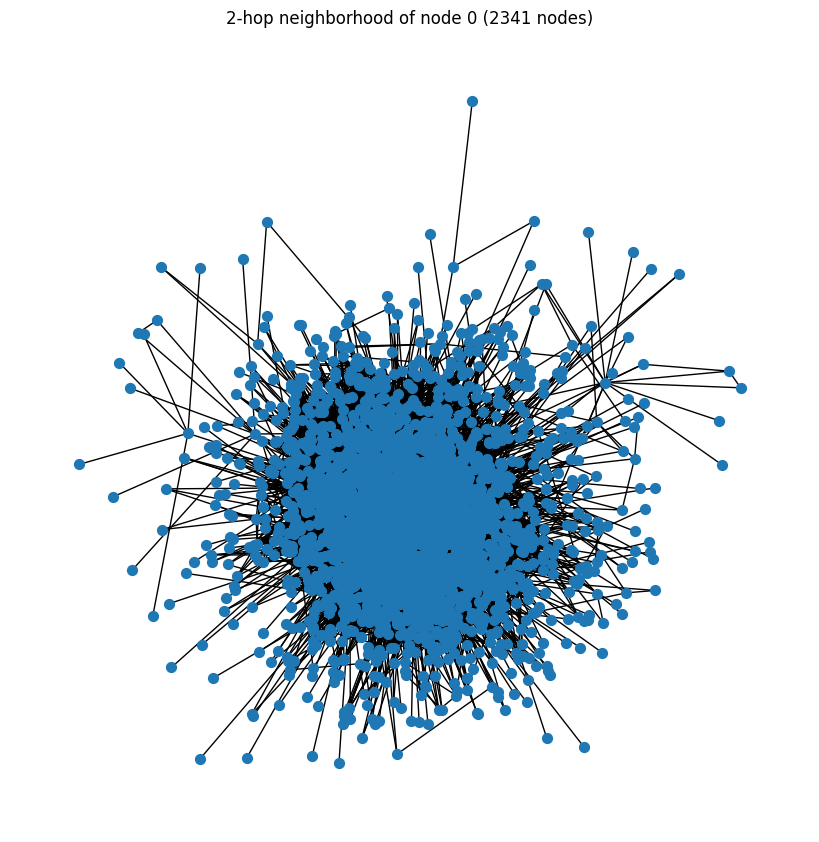

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx, k_hop_subgraph

# Pick one node and grab its 2-hop neighborhood
node_idx = 0
subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
    node_idx, num_hops=2, edge_index=data.edge_index, relabel_nodes=True
)

# Build a small PyG Data object just for this subgraph
from torch_geometric.data import Data
sub_data = Data(edge_index=sub_edge_index, num_nodes=subset.size(0))

G = to_networkx(sub_data, to_undirected=True)
plt.figure(figsize=(8, 8))
nx.draw(G, node_size=50, with_labels=False)
plt.title(f"2-hop neighborhood of node {node_idx} ({G.number_of_nodes()} nodes)")
plt.show()

Step 5 — Degree Distribution Analysis

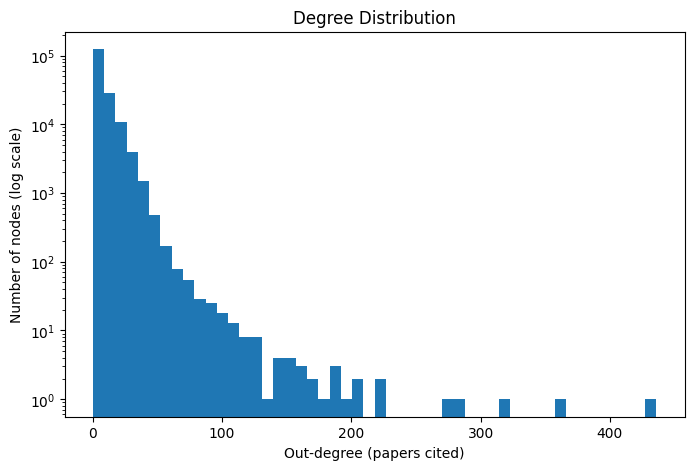

Mean out-degree: 6.886868476867676
Max out-degree: 436.0


In [ ]:
from torch_geometric.utils import degree

deg = degree(data.edge_index[0], num_nodes=data.num_nodes)  # out-degree (citations made)
deg_in = degree(data.edge_index[1], num_nodes=data.num_nodes)  # in-degree (citations received)

plt.figure(figsize=(8, 5))
plt.hist(deg.numpy(), bins=50, log=True)
plt.xlabel("Out-degree (papers cited)")
plt.ylabel("Number of nodes (log scale)")
plt.title("Degree Distribution")
plt.show()

print("Mean out-degree:", deg.mean().item())
print("Max out-degree:", deg.max().item())

Step 6 — Graph Density Analysis

In [ ]:
num_nodes = data.num_nodes
num_edges = data.edge_index.shape[1]
density = num_edges / (num_nodes * (num_nodes - 1))
print("Graph density:", density)

Graph density: 4.066840277668502e-05


Step 7 — Connected Component Analysis

In [ ]:
from torch_geometric.utils import to_undirected
from torch_geometric.transforms import ToUndirected
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

# Build a sparse adjacency matrix directly (fast, avoids full NetworkX conversion)
edge_index_undirected = to_undirected(data.edge_index)
row, col = edge_index_undirected.numpy()
adj = sp.csr_matrix((torch.ones(row.shape[0]), (row, col)), shape=(num_nodes, num_nodes))

n_components, labels = connected_components(adj, directed=False)
print("Number of connected components:", n_components)

import numpy as np
component_sizes = np.bincount(labels)
print("Largest component size:", component_sizes.max())
print("Number of isolated/tiny components:", (component_sizes < 5).sum())

Number of connected components: 1
Largest component size: 169343
Number of isolated/tiny components: 0


## Graph Analysis Report — OGBN-Arxiv

**1. Graph Overview**
The OGBN-Arxiv graph contains [num_nodes] nodes, where each node represents a
research paper, and [num_edges] directed edges, where an edge from paper A to
paper B represents A citing B.

**2. Node Features**
Each node has a [128]-dimensional feature vector derived from averaging word
embeddings of the paper's title and abstract. Feature values range from
[min] to [max], with a mean of [mean].

**3. Subgraph Visualization**
The 2-hop neighborhood of node [X] contains [N] nodes. [Describe what you
see — e.g., "a dense cluster around the central paper, suggesting it belongs
to a well-connected sub-field" or "a sparse, star-like structure."]

**4. Degree Distribution**
The mean out-degree is [value] and the mean in-degree is [value], with a
maximum of [value]. The distribution is heavily right-skewed [or describe
what your histogram actually shows] — most papers cite only a handful of
others, while a small number of highly-cited papers act as hubs. This is
consistent with the power-law pattern typical of citation networks.

**5. Graph Density**
The graph density is [value], which is extremely close to zero. This
confirms the graph is very sparse: each paper connects to only a tiny
fraction of the ~169,000 total papers, which is expected — no single paper
could realistically cite a meaningful percentage of the whole dataset.

**6. Connected Components**
The graph has [n_components] connected components. The largest component
contains [size] nodes ([percentage]% of all nodes), meaning the graph is
[mostly one giant connected structure / fragmented into many pieces —
describe what you actually found]. The remaining [n] components are small,
likely representing papers that cite or are cited by very few others
(e.g., niche topics or newer papers with limited citation history yet).

**7. Key Takeaway**
Overall, this graph exhibits the classic structure of a real-world citation
network: sparse, hub-dominated, and mostly connected — properties that make
it well-suited for graph-based learning methods like GNNs, since a paper's
category can often be inferred from the categories of papers it cites and
is cited by.